In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

## Lecture 15 ##

## Probability  with Random Sampling ##

Population:  </br>
Sample: 

### Types of Samples ###

Systematic: </br>
SRS - Simple Random Sample: 


We load in a dataset of all United flights national flights from 6/1/15 to 8/9/15, their destination and how long they were delayed, in minutes.

In [2]:
united = Table.read_table('united.csv')
united = united.with_column('Row', np.arange(united.num_rows)).move_to_start('Row')
united

Row,Date,Flight Number,Destination,Delay
0,6/1/15,73,HNL,257
1,6/1/15,217,EWR,28
2,6/1/15,237,STL,-3
3,6/1/15,250,SAN,0
4,6/1/15,267,PHL,64
5,6/1/15,273,SEA,-6
6,6/1/15,278,SEA,-8
7,6/1/15,292,EWR,12
8,6/1/15,300,HNL,20
9,6/1/15,317,IND,-10


Some deterministic samples:

In [3]:
united.where('Destination', 'JFK') 

Row,Date,Flight Number,Destination,Delay
26,6/1/15,502,JFK,-4
33,6/1/15,637,JFK,141
39,6/1/15,704,JFK,-8
50,6/1/15,758,JFK,-5
51,6/1/15,760,JFK,352
56,6/1/15,824,JFK,3
57,6/1/15,898,JFK,290
179,6/2/15,502,JFK,0
188,6/2/15,637,JFK,202
194,6/2/15,704,JFK,-11


In [4]:
united.take(np.arange(0, united.num_rows, 1000))

Row,Date,Flight Number,Destination,Delay
0,6/1/15,73,HNL,257
1000,6/7/15,1692,EWR,7
2000,6/14/15,824,JFK,-1
3000,6/21/15,217,EWR,5
4000,6/27/15,1401,SAN,-4
5000,7/4/15,1614,LAS,-2
6000,7/11/15,401,CLE,4
7000,7/17/15,1645,IAD,0
8000,7/24/15,624,ORD,61
9000,7/30/15,1728,ORD,209


In [5]:
united.take(make_array(34, 6321, 10040))

Row,Date,Flight Number,Destination,Delay
34,6/1/15,650,AUS,44
6321,7/13/15,1124,SEA,-7
10040,8/6/15,1216,LAS,2


Deterministic Samples can be biased samples. 
Why?

A random sample:</br>
The code below is similar to the second deterministic sample. What makes it random?

What sampling technique is being used?

In [6]:
start = np.random.choice(np.arange(100))
systematic_sample = united.take(np.arange(start, united.num_rows, 1000))
systematic_sample.show()

Row,Date,Flight Number,Destination,Delay
92,6/1/15,1267,SAN,-1
1092,6/8/15,864,BOS,-3
2092,6/15/15,222,LAX,-1
3092,6/21/15,1460,EWR,0
4092,6/28/15,500,EWR,54
5092,7/5/15,1060,IAH,-7
6092,7/11/15,1912,BOS,0
7092,7/18/15,758,JFK,5
8092,7/24/15,1742,EWR,183
9092,7/31/15,1038,LAS,12


The code below also generates a random sample. Why?

What sampling technique is being used?

In [7]:
united.sample(10, with_replacement=False)

Row,Date,Flight Number,Destination,Delay
10713,8/10/15,1937,IAH,34
1356,6/10/15,322,SEA,8
5885,7/10/15,1109,DEN,54
12269,8/21/15,273,SEA,-4
10398,8/8/15,1796,IAD,2
8156,7/25/15,599,BOS,-4
7893,7/23/15,1497,SEA,-3
7952,7/23/15,1975,FLL,0
13071,8/26/15,1669,ORD,-2
4248,6/29/15,698,MCO,49


In [8]:
# How do we use the sample command?
united.sample?

Signature: united.sample(k=None, with_replacement=True, weights=None)
Docstring:
Return a new table where k rows are randomly sampled from the
original table.

Args:
    ``k`` -- specifies the number of rows (``int``) to be sampled from
       the table. Default is k equal to number of rows in the table.

    ``with_replacement`` -- (``bool``) By default True;
        Samples ``k`` rows with replacement from table, else samples
        ``k`` rows without replacement.

    ``weights`` -- Array specifying probability the ith row of the
        table is sampled. Defaults to None, which samples each row
        with equal probability. ``weights`` must be a valid probability
        distribution -- i.e. an array the length of the number of rows,
        summing to 1.

Raises:
    ValueError -- if ``weights`` is not length equal to number of rows
        in the table; or, if ``weights`` does not sum to 1.

Returns:
    A new instance of ``Table`` with ``k`` rows resampled.

>>> jobs = Table(

## Distributions ##
Probability distributions list....
    
Theoretical is based on the possible outcomes.

Empirical is based on outcomes that occured in an experiment or observation. 

In [9]:
# A table of the faces of a six-sided die.

die = Table().with_column('Face', np.arange(1, 7))
die

Face
1
2
3
4
5
6


In [10]:
# Using the sample command, create a sample of 10 rolls from the above table. 
# What are the defaults? What are we expecting to be returned?

die.sample(10)

Face
4
4
1
6
3
3
1
6
1
6


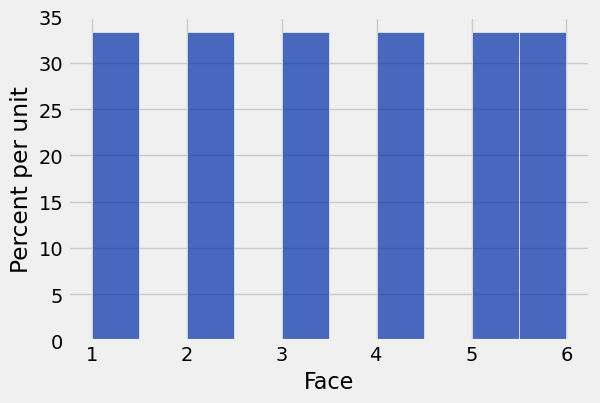

In [11]:
#Histogram of the original table with default bins. 
# What are the defaults?
# What is displayed?
# Calculate the percentage for each value based on the area of the rectangle.

die.hist()

In [12]:
# Defining our own bins. What are we changing?

roll_bins = np.arange(0.5, 6.6, 1)

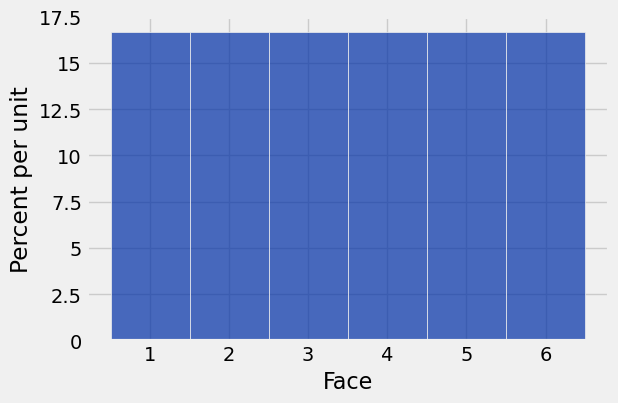

In [13]:
# Display the same histograms with our defined bins. 
# Calculate the percentage based on the new bins.
# Enter your code here

die.hist(bins=roll_bins)

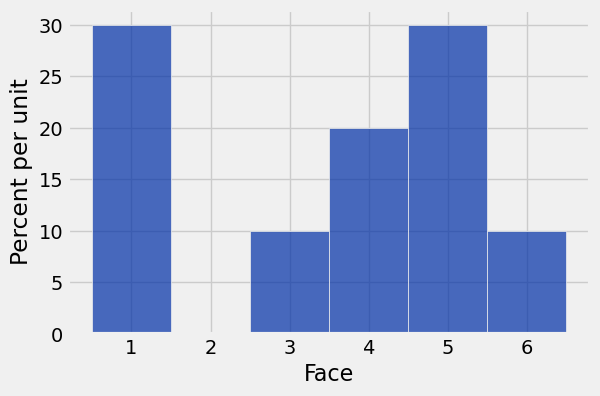

In [14]:
# Empirical Histogram of 10 die rolls
# Why is this histogram empirical?

die.sample(10).hist(bins=roll_bins)

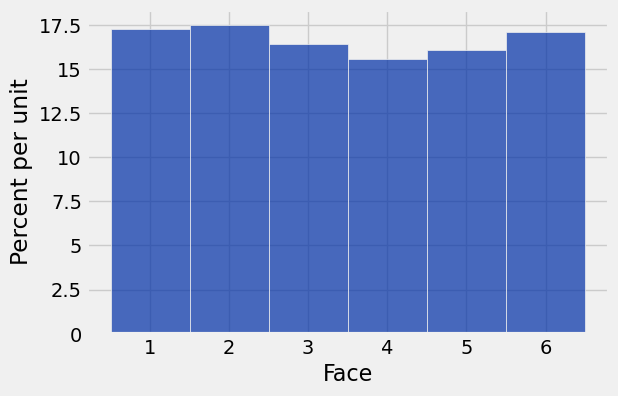

In [15]:
# Another empirical histogram. What has changed?

die.sample(1000).hist(bins=roll_bins)

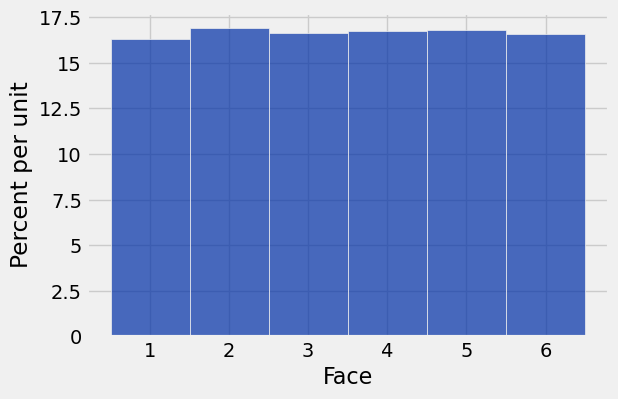

In [16]:
# Another empirical histogram. What has changed? What is happening as we make this change?

die.sample(100000).hist(bins=roll_bins)

## Large Random Samples ##

In [17]:
# This is our population. All the flights that occured in the summer of 2015.
# June, July, and August.
united

Row,Date,Flight Number,Destination,Delay
0,6/1/15,73,HNL,257
1,6/1/15,217,EWR,28
2,6/1/15,237,STL,-3
3,6/1/15,250,SAN,0
4,6/1/15,267,PHL,64
5,6/1/15,273,SEA,-6
6,6/1/15,278,SEA,-8
7,6/1/15,292,EWR,12
8,6/1/15,300,HNL,20
9,6/1/15,317,IND,-10


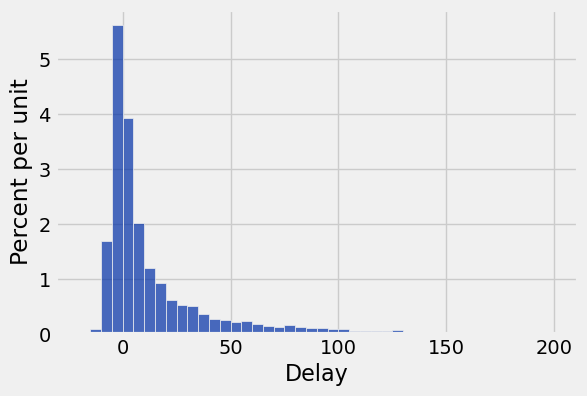

In [18]:
# Display the true histogram of flight delay times. 
united_bins = np.arange(-20, 201, 5)
united.hist('Delay', bins = united_bins)

In [19]:
#Direct Calculate the Percent where the delay is between 0 and 5 minutes and compare to the bar.
#How do we direct calculate the percent from the table?
#Enter your code below. 

flight_delay_0_5 = united.where('Delay', are.between(0,5)).num_rows
flight_all = united.num_rows

flight_delay_0_5 / flight_all

0.19406871609403256

In [22]:
# Determine the shortest delay?
# What does this value represent?
# Enter your code below.

shortest_delay = min(united.column('Delay'))
shortest_delay

-16

In [23]:
# Determine the longest delay?
# What does this value represent?
# Enter your code below.

longest_delay = max(united.column('Delay'))
longest_delay

580

In [24]:
# Determine the average delay?
# What does this value represent?
# Enter your code below.

average_delay = np.average(united.column('Delay'))
average_delay

16.658155515370705

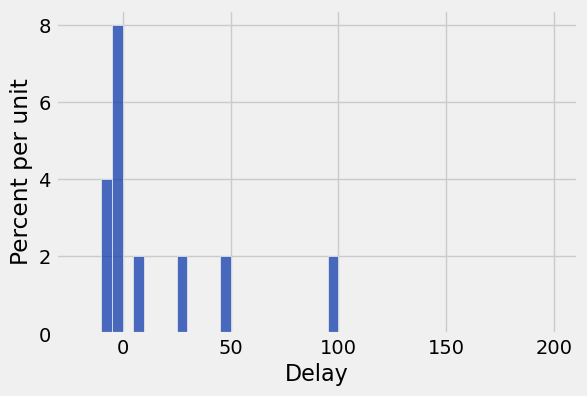

In [25]:
# Using the same bins as the population histogram. Create a histogram for a sample of 10.

united.sample(10).hist('Delay', bins = united_bins)

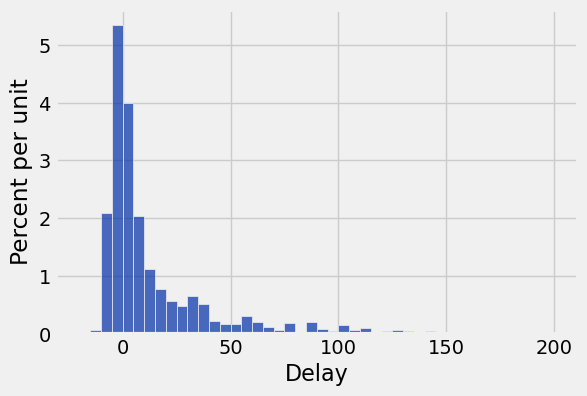

In [26]:
# Using the same bins as the population histogram. Create a histogram for a sample of 1000.

united.sample(1000).hist('Delay', bins = united_bins)

What observations can you make as you compare the sample histograms with the population histogram?

## Simulating Statistics ##

Whenever our histogram is skewed. The median (middle value) will be a better measure of center than the mean (average).

Why do you think that is?

In [27]:
# Find the true median of the population delay times.

np.median(united.column('Delay'))

2.0

In [28]:
# Use the median command to find the median of a sample of 10 delay times.
# Enter your code below.

np.median(united.sample(10).column('Delay'))

-3.0

In [29]:
# Create a function that will give the sample median of a sample size of n.
# Enter your code below. 
# Name your function sample_median

def generic_sample_median(table, size, column):
    return np.median(table.sample(size).column(column))

def sample_median(size):
    return np.median(united.sample(size).column('Delay'))

In [31]:
# Test your function for a sample of size 100.

sample_median(50)

3.5

In [32]:
# Create a for loop that will run the sample median function for a sample of 10, one thousand times. 
# Complete the code below.

sample_medians = make_array()

for i in np.arange(1000):
    new_median = sample_median(10)
    sample_medians = np.append(sample_medians, new_median)

sample_medians

array([  7. ,  -2. ,   4. ,   4.5,   6. ,   3. ,  -1. ,   4. ,   2.5,
         5. ,   7.5,   6.5,   2. ,  -1. ,  13.5,  -0.5,   4. ,  24. ,
         6.5,   6. ,   6.5,   1. ,  -2.5,   1.5,   4. ,  -0.5,   2.5,
         0.5,   3. ,   0.5,   4. ,  -2.5,   2. ,   0.5,  -3.5,   3.5,
         0.5,  15.5,   0.5,   3. ,   6.5,   4. ,   9.5,   7. ,   6. ,
         6. ,   4. ,   3. ,   6.5,   1. ,  -0.5,   0. ,  11. ,  11.5,
        13.5,   6. ,  13.5,  -1.5,   2.5,   4.5,   0. ,  14.5,   0. ,
         0.5,  -1. ,   4.5,   0.5,  10.5,  -0.5,   3.5,   5.5,   0. ,
        21.5,   2. ,   8. ,  -1.5,   4.5,  11.5,   5.5,   4. ,  11. ,
         4. ,  -1. ,   4. ,   1. ,   3. ,   4. ,   2.5,   4. ,   2.5,
         1. ,  -0.5,  -0.5,   5.5,   5. ,   3. ,   5. ,   0.5,  12.5,
         0.5,  -1. ,   3.5,  12. ,   4. ,   3.5,  -0.5,   3. ,  14.5,
         3. ,  10. ,   3. ,   5.5,   3.5,   0.5,   0. ,  -2.5,   1. ,
         2.5,  19.5,  12.5,  -3.5,   4. ,   0.5,   1. ,   0. ,  17. ,
         0. ,  11.5,

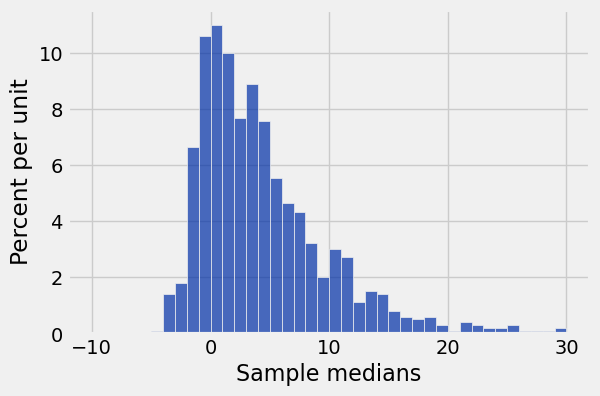

In [33]:
# The below code converts the array into a table, then displays a histogram with the defined bins.

Table().with_column('Sample medians', sample_medians).hist(bins = np.arange(-10,31))

What observations can you make about United delays in the summer of 2015?

If you were running United, how might this information help you?

In [35]:
# Duplicate the code above to run 1000 iterations for samples of 1000.

sample_medians = make_array()

for i in np.arange(1000):
    new_median = sample_median(1000)
    sample_medians = np.append(sample_medians, new_median)

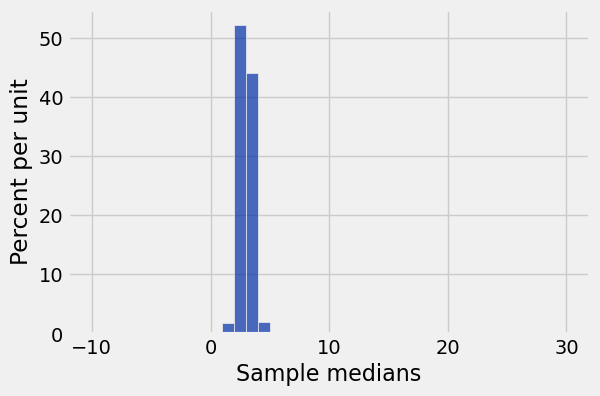

In [36]:
# What does this code do?

Table().with_column(
    'Sample medians', sample_medians).hist(bins = np.arange(-10,31))

In [ ]:
What observations can you make about the new histogram?